# Pose Scoring Model Training

### Block 1: Imports
This block imports all necessary libraries for data manipulation, model training, and visualization.

In [1]:
import numpy as np
import json
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from services.ScoringService import ScoringService
from services.ClassifyingService import ClassifyingService
from services.VisualisationService import save_visualized_video
from repositories.MediapipeSegmentationRepository import MediapipeSegmentationRepository

### Block 2: Configuration
This block defines constants for file paths, number of segments, and pose labels.

In [2]:
video_folder = "./dataset/videos/handstand"
pose_scores_csv = "./dataset/labels/beoordeling.csv"
pose_labels_csv = "./dataset/labels/pose_labels.csv"
skeletons_json = "./dataset/skeletons/handstand_cos_skeletons.json"
num_segments = 10
pose_labels = {
    0: ["beginpositie"],
    1: ["opzwaai"],
    2: ["handplaatsing", "lichaamshouding"],
    3: ["landing"]
}
pose_names = ["starting", "swing", "handstand", "landing"]

### Block 3: Skeleton Feature Extraction
This block processes all videos in the `video_folder` to extract skeleton features using the `MediapipeSegmentationRepository`. The extracted features are saved to a JSON file. If the JSON file already exists, this step is skipped.

In [3]:
if not os.path.exists(skeletons_json):
    segmentation_repository = MediapipeSegmentationRepository()
    video_names = os.listdir(video_folder)
    videos_score_data = {}
    for video_name in tqdm(video_names):
        videos_score_data[video_name] = {}
        full_video_path = os.path.join(video_folder, video_name)
        frames, feature_tensor, mask = segmentation_repository.process_video_cosine_segments(full_video_path)
        videos_score_data[video_name]["features"] = [[segment[0] for segment in frame] + \
                                                     [segment[1] for segment in frame]\
                                                     for frame in feature_tensor.tolist()]
        videos_score_data[video_name]["mask"] = mask.tolist()
    with open(skeletons_json, 'w') as f:
        json.dump(videos_score_data, f, indent=4)
else:
    print(f"{skeletons_json} already exists. Skipping feature extraction.")

./dataset/skeletons/handstand_cos_skeletons.json already exists. Skipping feature extraction.


### Block 4: Pose Label Processing Functions
This block defines helper functions to process pose labels from the CSV file and align them with the skeleton data. These functions handle the logic for creating one-hot encoded pose sequences for each video.

In [4]:
def process_pose_labels(pose_labels_csv, skeletons_json):
    pose_labels = pd.read_csv(pose_labels_csv)
    pose_names = list(pose_labels.columns[1:])
    num_poses = len(pose_names)
    with open(skeletons_json, 'r') as f:
        videos_score_data = json.load(f)
    features = []
    targets = []
    video_names = []
    for video_name, video_data in videos_score_data.items():
        cos_angles = np.array(video_data["features"])
        mask = np.array(video_data["mask"])
        num_frames = len(mask)
        video_row = pose_labels[pose_labels["videoname"] == video_name]
        if video_row.empty:
            print(f"Warning: {video_name} not found in pose labels, skipping...")
            continue
        start_frames = []
        for pose_name in pose_names:
            frame = int(video_row[pose_name].values[0])
            start_frames.append(frame)
        start_frames = process_start_frames(start_frames, num_frames)
        pose_sequence = generate_pose_sequence(start_frames, num_frames, num_poses)
        actual_start = find_actual_start(start_frames)
        cos_angles = cos_angles[actual_start:]
        mask = mask[actual_start:]
        pose_sequence = pose_sequence[actual_start:]
        valid_indices = mask.astype(bool)
        cos_angles = cos_angles[valid_indices]
        pose_sequence = pose_sequence[valid_indices]
        if len(cos_angles) > 0:
            features.append(cos_angles)
            targets.append(pose_sequence)
            video_names.append(video_name)
        else:
            print(f"Warning: {video_name} has no valid frames after masking, skipping...")
    return features, targets, video_names, pose_names

def process_start_frames(start_frames, num_frames):
    processed = start_frames.copy()
    num_poses = len(processed)
    first_valid_idx = -1
    for i, frame in enumerate(processed):
        if frame != -1:
            first_valid_idx = i
            break
    if first_valid_idx == -1:
        return processed
    last_valid_idx = -1
    for i in range(num_poses - 1, -1, -1):
        if processed[i] != -1:
            last_valid_idx = i
            break
    return processed

def find_actual_start(start_frames):
    for frame in start_frames:
        if frame != -1:
            return frame
    return 0

def generate_pose_sequence(start_frames, num_frames, num_poses):
    pose_sequence = np.zeros((num_frames, num_poses), dtype=np.float32)
    valid_poses = []
    for pose_id, start_frame in enumerate(start_frames):
        if start_frame != -1:
            valid_poses.append((start_frame, pose_id))
    if not valid_poses:
        return pose_sequence
    valid_poses.sort(key=lambda x: x[0])
    last_valid_idx = -1
    for i in range(len(start_frames) - 1, -1, -1):
        if start_frames[i] != -1:
            last_valid_idx = i
            break
    has_trailing_invalid = last_valid_idx < len(start_frames) - 1
    for i, (start_frame, pose_id) in enumerate(valid_poses):
        if i < len(valid_poses) - 1:
            end_frame = valid_poses[i + 1][0]
        else:
            if has_trailing_invalid:
                end_frame = min(start_frame + 20, num_frames)
            else:
                end_frame = num_frames
        pose_sequence[start_frame:end_frame, pose_id] = 1.0
    return pose_sequence

### Block 5: Scoring Data Preparation
This block prepares the data for training the scoring models. It loads the skeleton features and pose labels, reads the scores from the CSV file, and then creates feature-target pairs for each pose. The features are the sequences of joint data for frames belonging to a pose, and the target is the calculated score for that pose in a specific video.

In [5]:
features, targets, video_names, _ = process_pose_labels(pose_labels_csv, skeletons_json)
scores_df = pd.read_csv(pose_scores_csv)

def prepare_scoring_data(features, targets, video_names, scores_df, pose_labels, num_segments):
    features_per_pose = {i: [] for i in range(len(pose_labels))}
    targets_per_pose = {i: [] for i in range(len(pose_labels))}

    for video_idx, video_name in enumerate(video_names):
        video_scores = scores_df[scores_df["video_name"] == video_name]
        if video_scores.empty:
            continue

        video_features = features[video_idx]
        video_targets = targets[video_idx]
        pose_indices = np.argmax(video_targets, axis=1)

        for pose_id in range(len(pose_labels)):
            pose_specific_features = video_features[pose_indices == pose_id]
            if len(pose_specific_features) > 0:
                features_per_pose[pose_id].append(pose_specific_features)
                
                # Calculate target score
                score_labels = pose_labels[pose_id]
                mean_score = video_scores[score_labels].mean(axis=1).values[0]
                num_frames = len(pose_specific_features)
                target_scores_for_sequence = []
                for frame_idx in range(num_frames):
                    scaler = 1 - abs((frame_idx+1) - (num_frames * 0.5)) / num_frames # If in the middle == 1, if on the edge == 0.5
                    target_scores_for_sequence.append([mean_score*scaler] * num_segments)
                target_scores_for_sequence = np.array(target_scores_for_sequence)
                targets_per_pose[pose_id].append(target_scores_for_sequence)
                
    return features_per_pose, targets_per_pose

features_per_pose, targets_per_pose = prepare_scoring_data(features, targets, video_names, scores_df, pose_labels, num_segments)

### Block 6: Train Scoring Models
This block trains a separate regression model for each pose to predict its score. It iterates through each pose, prepares the data, trains a `ScoringService` model, and saves the weights. Training metrics are plotted for each model.

--- Training Scoring Model for Pose: starting (0) ---
Created 1380 training samples from 42 sequences
Created 352 validation samples from 11 sequences


Training:   0%|          | 0/200 [00:00<?, ?it/s]/mnt/c/Users/Tofa/source/WorkProjects/GymnasticsAnalysis/Training/ScoringModels/services/ScoringService.py:174: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  batch_y = torch.tensor(batch_targets, dtype=torch.float32).to(self.device)
Training:  38%|███▊      | 76/200 [00:18<00:29,  4.22it/s, Loss: 0.0484 | Val Loss: 0.0931]



Early stopping at epoch 77

Training History:


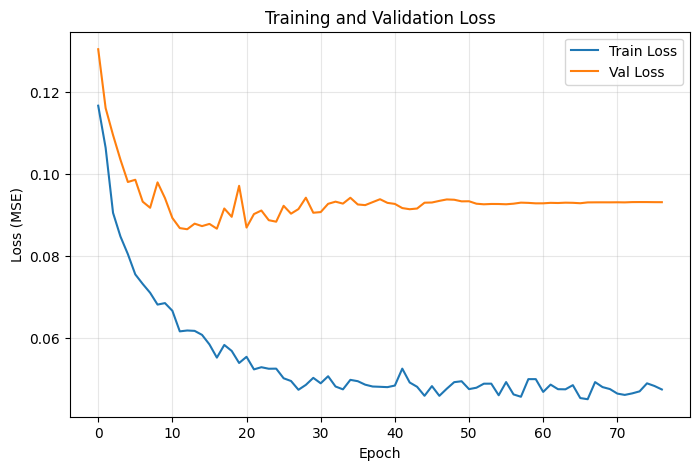

Model saved to ./model_weights/scoring_model0/scoring_model_pose_0.pth
Scoring model for pose 0 saved to ./model_weights/scoring_model0/scoring_model_pose_0.pth
--- Training Scoring Model for Pose: swing (1) ---
Created 1429 training samples from 57 sequences
Created 229 validation samples from 15 sequences


Training:  34%|███▍      | 69/200 [00:16<00:31,  4.13it/s, Loss: 0.0284 | Val Loss: 0.0522]


Early stopping at epoch 70

Training History:


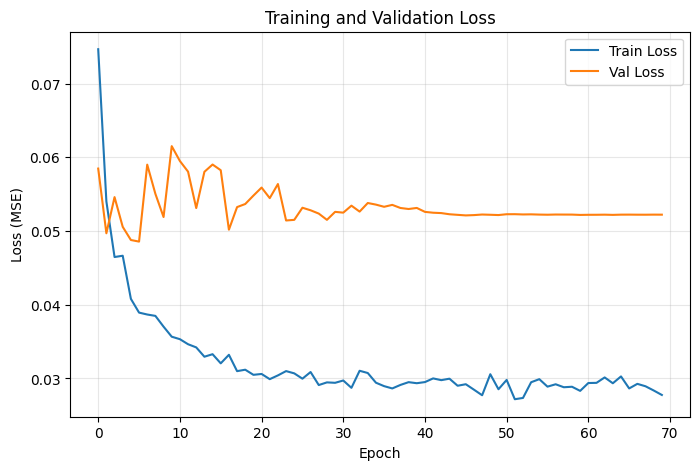

Model saved to ./model_weights/scoring_model0/scoring_model_pose_1.pth
Scoring model for pose 1 saved to ./model_weights/scoring_model0/scoring_model_pose_1.pth
--- Training Scoring Model for Pose: handstand (2) ---
Created 2668 training samples from 56 sequences
Created 856 validation samples from 15 sequences


Training:  34%|███▎      | 67/200 [00:27<00:54,  2.46it/s, Loss: 0.0292 | Val Loss: 0.0468]


Early stopping at epoch 68

Training History:


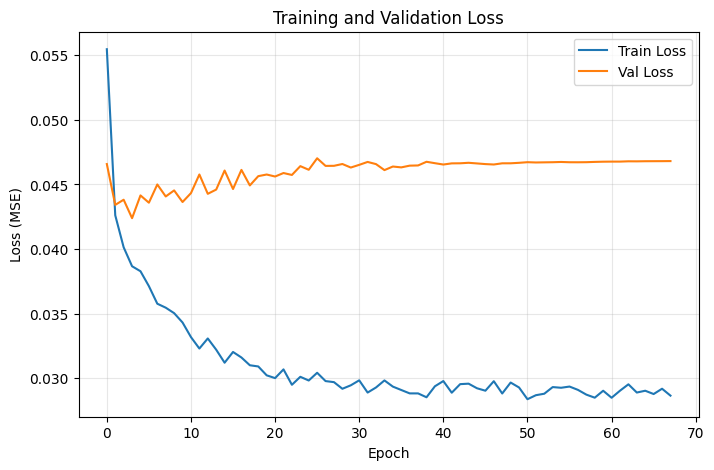

Model saved to ./model_weights/scoring_model0/scoring_model_pose_2.pth
Scoring model for pose 2 saved to ./model_weights/scoring_model0/scoring_model_pose_2.pth
--- Training Scoring Model for Pose: landing (3) ---
Created 1040 training samples from 57 sequences
Created 358 validation samples from 15 sequences


Training:  32%|███▎      | 65/200 [00:12<00:25,  5.35it/s, Loss: 0.0566 | Val Loss: 0.1568]



Early stopping at epoch 66

Training History:


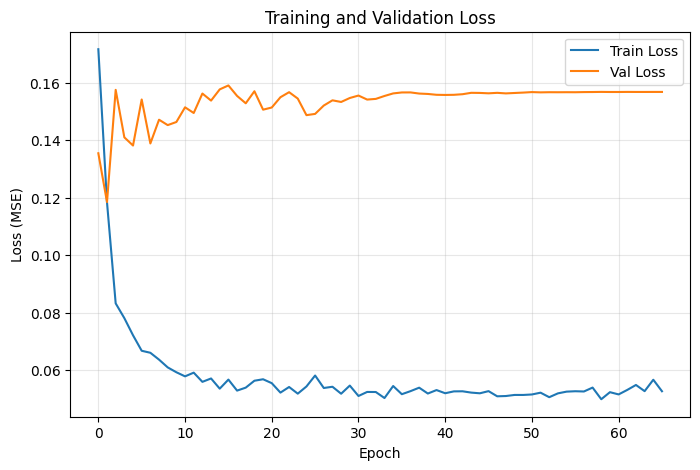

Model saved to ./model_weights/scoring_model0/scoring_model_pose_3.pth
Scoring model for pose 3 saved to ./model_weights/scoring_model0/scoring_model_pose_3.pth
--- All scoring models trained ---


In [ ]:
for pose_id in range(len(pose_labels)):
    print(f"--- Training Scoring Model for Pose: {pose_names[pose_id]} ({pose_id}) ---")
    
    if not features_per_pose[pose_id]:
        print(f"No data available for pose {pose_id}. Skipping.")
        continue
        
    # Split data
    x_train, x_test, y_train, y_test = train_test_split(
        features_per_pose[pose_id], targets_per_pose[pose_id], test_size=0.2)
    
    # Create and train the model
    scorer = ScoringService(
        window_size=2,
        hidden_size=64,
        num_layers=4,
        dropout=0.5,
        batch_size=64,
        epochs=200,
        patience=64,
        device="cuda:0",
        augment=True,
        augment_scale_range=(0.97, 1.03),
        use_joint_attention=True,
        use_temporal_attention=True,
        num_outputs=num_segments)
    
    scorer.fit(x_train, y_train, x_test, y_test)
    
    print("\nTraining History:")
    scorer.plot_history()
    
    # Save model
    model_save_path = f'./model_weights/scoring_model0/scoring_model_pose_{pose_id}.pth'
    scorer.save_model(model_save_path)
    print(f"Scoring model for pose {pose_id} saved to {model_save_path}")

print("--- All scoring models trained ---")

# The classification model training would go here, if needed.
# For now, we assume a pre-trained classification model exists or will be trained separately.

### Block 7: Process Test Video and Predict Scores
This block demonstrates how to use the trained models to analyze a test video. It first uses a pre-trained pose classification model to identify pose segments in the video. Then, for each segment, it uses the corresponding scoring model (trained in the previous block) to predict a score. The final output is a set of annotations for each frame, including the predicted pose and the score for the current segment.

In [10]:
test_video_path = "./dataset/videos/test/video_2026-01-16_10-25-40.mp4"
classification_model_path = './model_weights/gruClassifier7821.pth'

# Load pre-trained pose classifier
classifier = ClassifyingService(
    num_classes=4,
    input_size=20,
    window_size=24,
    hidden_size=32,
    num_layers=3,
    dropout=0.5,
    batch_size=256,
    epochs=200,
    patience=64,
    class_names=("Starting", "Swing", "Handstand", "Landing"),
    device="cuda:0",
    augment=True,
    augment_scale_range=(0.99, 1.00),
    use_joint_attention=True,
    use_temporal_attention=True)

classifier.load_model(classification_model_path)

# Load scoring models
scoring_models = {}
for pose_id in range(len(pose_labels)):
    model_path = f'./model_weights/scoring_model0/scoring_model_pose_{pose_id}.pth'
    if os.path.exists(model_path):
        scorer = ScoringService(
            window_size=2,
            hidden_size=64,
            num_layers=4,
            dropout=0.5,
            device="cuda:0",
            use_joint_attention=True,
            use_temporal_attention=True,
            num_outputs=num_segments) # Set num_outputs
        scorer.input_size = 20 # Manually set based on classifier skeleton features
        scorer.load_model(model_path)
        scoring_models[pose_id] = scorer

# Process test video
segmentation_repo = MediapipeSegmentationRepository()
# Make sure to process the *full* frames for visualization, not just the masked ones
all_frames_data, feature_tensor, mask = segmentation_repo.process_video_cosine_segments(test_video_path)

# Features for prediction should be from the masked frames
video_features = [[segment[0] for segment in frame] + [segment[1] for segment in frame] for frame in feature_tensor[mask].tolist()]

# Predict poses for the valid (masked) frames
predictions, probabilities = classifier.predict_frames([video_features])
predicted_poses = predictions[0]

# --- Process segments, get scores, and prepare annotations ---
# Annotations should correspond to the original number of frames
frame_annotations = [{} for _ in range(len(all_frames_data))]
valid_frame_indices = np.where(mask)[0] # Indices of frames that were not skipped

print("--- Segment Scores ---")

all_scores = []
if len(predicted_poses) > 0:
    current_pose = predicted_poses[0]
    segment_start_idx = 0 # Index within the predicted_poses array
    
    for i in range(1, len(predicted_poses)):
        if predicted_poses[i] != current_pose:
            # End of a segment
            segment_end_idx = i
            segment_features = video_features[segment_start_idx:segment_end_idx]
            
            if current_pose in scoring_models and len(segment_features) > 0:
                # Returns a list with one array of shape (num_frames, num_segments)
                segment_scores_per_frame = scoring_models[current_pose].predict_frames([segment_features])[0]
                all_scores.extend(list(segment_scores_per_frame))
                
                # For overall segment score, average all scores
                overall_segment_score = segment_scores_per_frame.mean()
                print(f"Segment: {pose_names[current_pose]:<10} | Frames: {valid_frame_indices[segment_start_idx]}-{valid_frame_indices[segment_end_idx-1]} | Score: {overall_segment_score:.3f}")

                # Annotate each frame in the original video
                for j in range(segment_start_idx, segment_end_idx):
                    original_frame_idx = valid_frame_indices[j]
                    frame_segment_scores = segment_scores_per_frame[j - segment_start_idx]
                    avg_frame_score = frame_segment_scores.mean()
                    
                    frame_annotations[original_frame_idx]['label'] = f'{pose_names[current_pose]} | Score: {avg_frame_score:.2f}'
                    frame_annotations[original_frame_idx]['segment_scores'] = {k: v for k, v in enumerate(frame_segment_scores)}

            # Start of new segment
            current_pose = predicted_poses[i]
            segment_start_idx = i

    # Process the last segment
    segment_end_idx = len(predicted_poses)
    segment_features = video_features[segment_start_idx:segment_end_idx]
    if current_pose in scoring_models and len(segment_features) > 0:
        segment_scores_per_frame = scoring_models[current_pose].predict_frames([segment_features])[0]
        all_scores.extend(list(segment_scores_per_frame))
        
        overall_segment_score = segment_scores_per_frame.mean()
        print(f"Segment: {pose_names[current_pose]:<10} | Frames: {valid_frame_indices[segment_start_idx]}-{valid_frame_indices[segment_end_idx-1]} | Score: {overall_segment_score:.3f}")

        for j in range(segment_start_idx, segment_end_idx):
            original_frame_idx = valid_frame_indices[j]
            frame_segment_scores = segment_scores_per_frame[j - segment_start_idx]
            avg_frame_score = frame_segment_scores.mean()
            
            frame_annotations[original_frame_idx]['label'] = f'{pose_names[current_pose]} | Score: {avg_frame_score:.2f}'
            frame_annotations[original_frame_idx]['segment_scores'] = {k: v for k, v in enumerate(frame_segment_scores)}

print(f"Total Score: {np.mean(all_scores):.3f}")
print("----------------------")


Model loaded from ./model_weights/gruClassifier7821.pth
Model loaded from ./model_weights/scoring_model0/scoring_model_pose_0.pth
Model loaded from ./model_weights/scoring_model0/scoring_model_pose_1.pth
Model loaded from ./model_weights/scoring_model0/scoring_model_pose_2.pth
Model loaded from ./model_weights/scoring_model0/scoring_model_pose_3.pth


I0000 00:00:1768841444.169716   12970 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1768841444.176751   14751 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: llvmpipe (LLVM 20.1.2, 256 bits)
W0000 00:00:1768841444.385121   14739 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1768841445.374497   14741 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


--- Segment Scores ---
Segment: starting   | Frames: 0-20 | Score: 0.005
Segment: swing      | Frames: 21-30 | Score: 0.822
Segment: handstand  | Frames: 31-40 | Score: 0.869
Segment: swing      | Frames: 41-45 | Score: 0.798
Segment: handstand  | Frames: 46-113 | Score: 0.766
Segment: landing    | Frames: 114-128 | Score: 0.596
Total Score: 0.636
----------------------


### Block 8: Visualize Results
This block saves a new video with the predicted pose labels and scores annotated on each frame. This provides a clear visual representation of the model's performance on the test video.

In [11]:
output_video_path = "./dataset/videos/test/test_scored.mp4"
save_visualized_video(output_video_path, 
                      all_frames_data, 
                      test_video_path,
                      frame_annotations=frame_annotations)